Below is my implementation of `MakeMore by Andrej Karpathy` on a different dataset containing muslim names.
We are trying to generate new muslim names by training on our dataset. Two approaches have been employed:
1. By creating a table which is mapping the bigram frequency i.e., how often a letter comes after the other. The counts are then normalised to give probabilities.
2. We train a simple neural network on the data which takes one letter and predicts the next character.

> The loss function for the neural network is the Negative Log Likelihood 

In [269]:
import matplotlib.pyplot as plt

In [270]:
words = open('muslimnames.csv',"r")
names = []
for i in words.readlines():
    j = i.split(",")
    names.append(j[0])
names

['Name',
 'aaban',
 'aabid',
 'aadil',
 'aahil',
 'aalam',
 'aalee',
 'aalim',
 'aamil',
 'aamir',
 'aaqib',
 'aaqil',
 'aarif',
 'aariz',
 'aaryan',
 'aashif',
 'aashir',
 'aasif',
 'aasim',
 'aatif',
 'aaus',
 'aayan',
 'aazim',
 'abaan',
 'abbas',
 'abbud',
 'abbudin',
 'abdal',
 'abdalala',
 'abdel',
 'abdul',
 'abdulaalee',
 'abduladheem',
 'abduladl',
 'abdulafuw',
 'abdulahad',
 'abdulaleem',
 'abdulalim',
 'abdulaliyy',
 'abdulawwal',
 'abdulazeez',
 'abdulazim',
 'abdulaziz',
 'abdulbaaqi',
 'abdulbaari',
 'abdulbaasit',
 'abdulbadee',
 'abdulbadi',
 'abdulbaith',
 'abdulbaqi',
 'abdulbari',
 'abdulbarr',
 'abdulbaseer',
 'abdulbasir',
 'abdulbasit',
 'abdulbatin',
 'abduldhahir',
 'abdulfattah',
 'abdulghafaar',
 'abdulghaffar',
 'abdulghafoor',
 'abdulghafur',
 'abdulghani',
 'abdulhadi',
 'abdulhafeedh',
 'abdulhafeez',
 'abdulhafiz',
 'abdulhakam',
 'abdulhakeem',
 'abdulhakim',
 'abdulhaleem',
 'abdulhalim',
 'abdulhameed',
 'abdulhamid',
 'abdulhannan',
 'abdulhaq',
 'ab

In [271]:
names = names[1:-1]

In [272]:
print(min(len(w) for w in names))
print(max(len(w)for w in names))

2
18


In [273]:
b = {}
for n in names:
    chs = ["<S>"] + list(n )+ ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

In [274]:
b

{('n', '<E>'): 477,
 ('d', '<E>'): 252,
 ('l', '<E>'): 215,
 ('m', '<E>'): 265,
 ('e', '<E>'): 28,
 ('r', '<E>'): 417,
 ('b', '<E>'): 161,
 ('f', '<E>'): 81,
 ('z', '<E>'): 91,
 ('s', '<E>'): 95,
 ('a', '<E>'): 983,
 ('w', '<E>'): 1,
 ('y', '<E>'): 29,
 ('i', '<E>'): 155,
 ('t', '<E>'): 114,
 ('h', '<E>'): 1012,
 ('q', '<E>'): 70,
 ('k', '<E>'): 27,
 ('o', '<E>'): 6,
 ('j', '<E>'): 27,
 ('.', '<E>'): 1,
 ('u', '<E>'): 2,
 (')', '<E>'): 1}

In [275]:
sorted(b.items(), key = lambda kv : -kv[1])

[(('h', '<E>'), 1012),
 (('a', '<E>'), 983),
 (('n', '<E>'), 477),
 (('r', '<E>'), 417),
 (('m', '<E>'), 265),
 (('d', '<E>'), 252),
 (('l', '<E>'), 215),
 (('b', '<E>'), 161),
 (('i', '<E>'), 155),
 (('t', '<E>'), 114),
 (('s', '<E>'), 95),
 (('z', '<E>'), 91),
 (('f', '<E>'), 81),
 (('q', '<E>'), 70),
 (('y', '<E>'), 29),
 (('e', '<E>'), 28),
 (('k', '<E>'), 27),
 (('j', '<E>'), 27),
 (('o', '<E>'), 6),
 (('u', '<E>'), 2),
 (('w', '<E>'), 1),
 (('.', '<E>'), 1),
 ((')', '<E>'), 1)]

In [276]:
print(len(names))
special_chars = {'/', '.', '(', ')'}
for name in names:
    if any(char in name for char in special_chars):
        print(name)
        names.remove(name)
print(len(names))

4510
marudeen.
hafsa/ucha
izzah(izzat)
4507


In [277]:
chars = sorted(list(set(''. join(names))))
stoi = {s : i for i, s in enumerate(chars)}
stoi['<S>'] = 25
stoi['<E>'] = 26
itos = {i : s for s, i in stoi.items()}
print(stoi)
print(itos)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'y': 23, 'z': 24, '<S>': 25, '<E>': 26}
{0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 9: 'j', 10: 'k', 11: 'l', 12: 'm', 13: 'n', 14: 'o', 15: 'p', 16: 'q', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'y', 24: 'z', 25: '<S>', 26: '<E>'}


In [278]:
import torch 
N =torch.zeros((27,27), dtype = torch.int32)

In [279]:
for name in names:
  chs = ['<S>'] + list(name) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

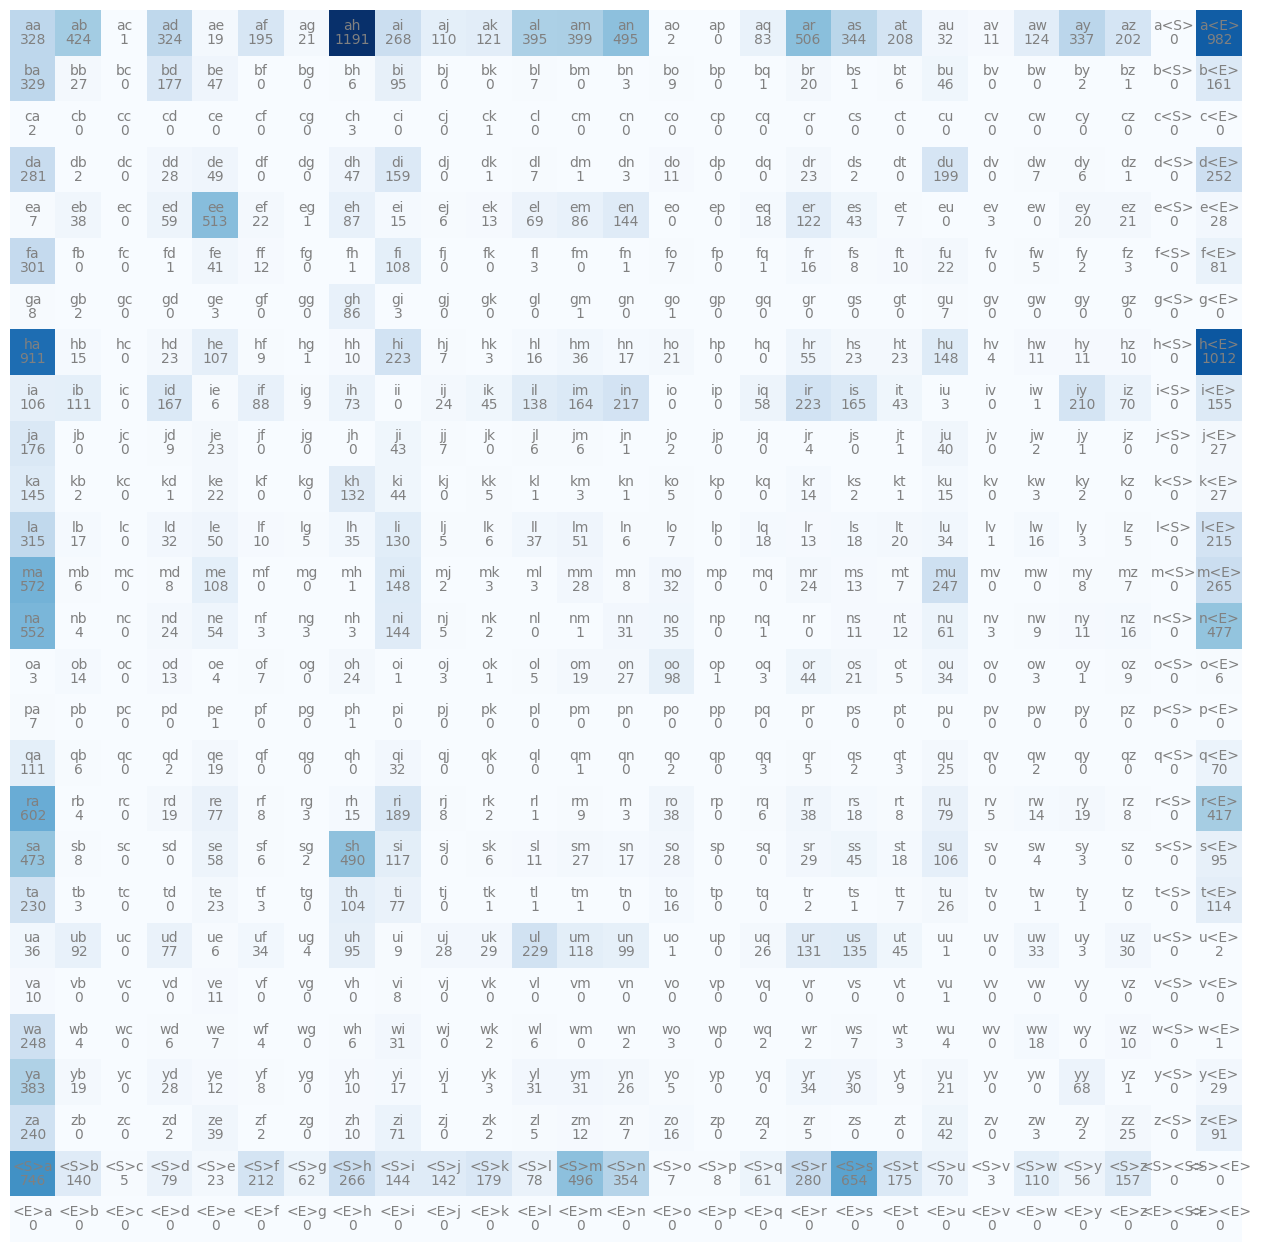

In [280]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


In [281]:
N =torch.zeros((26,26), dtype = torch.int32)

In [282]:
# we have some redundant data in the above rows such as <E> being the first letter and <S> not being the first letter let's fix that
# lets have only one special token instead of 2 

stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

for name in names:
  chs = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

chars = sorted(list(set(''. join(names))))

print(stoi)
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'y': 24, 'z': 25, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'y', 25: 'z', 0: '.'}


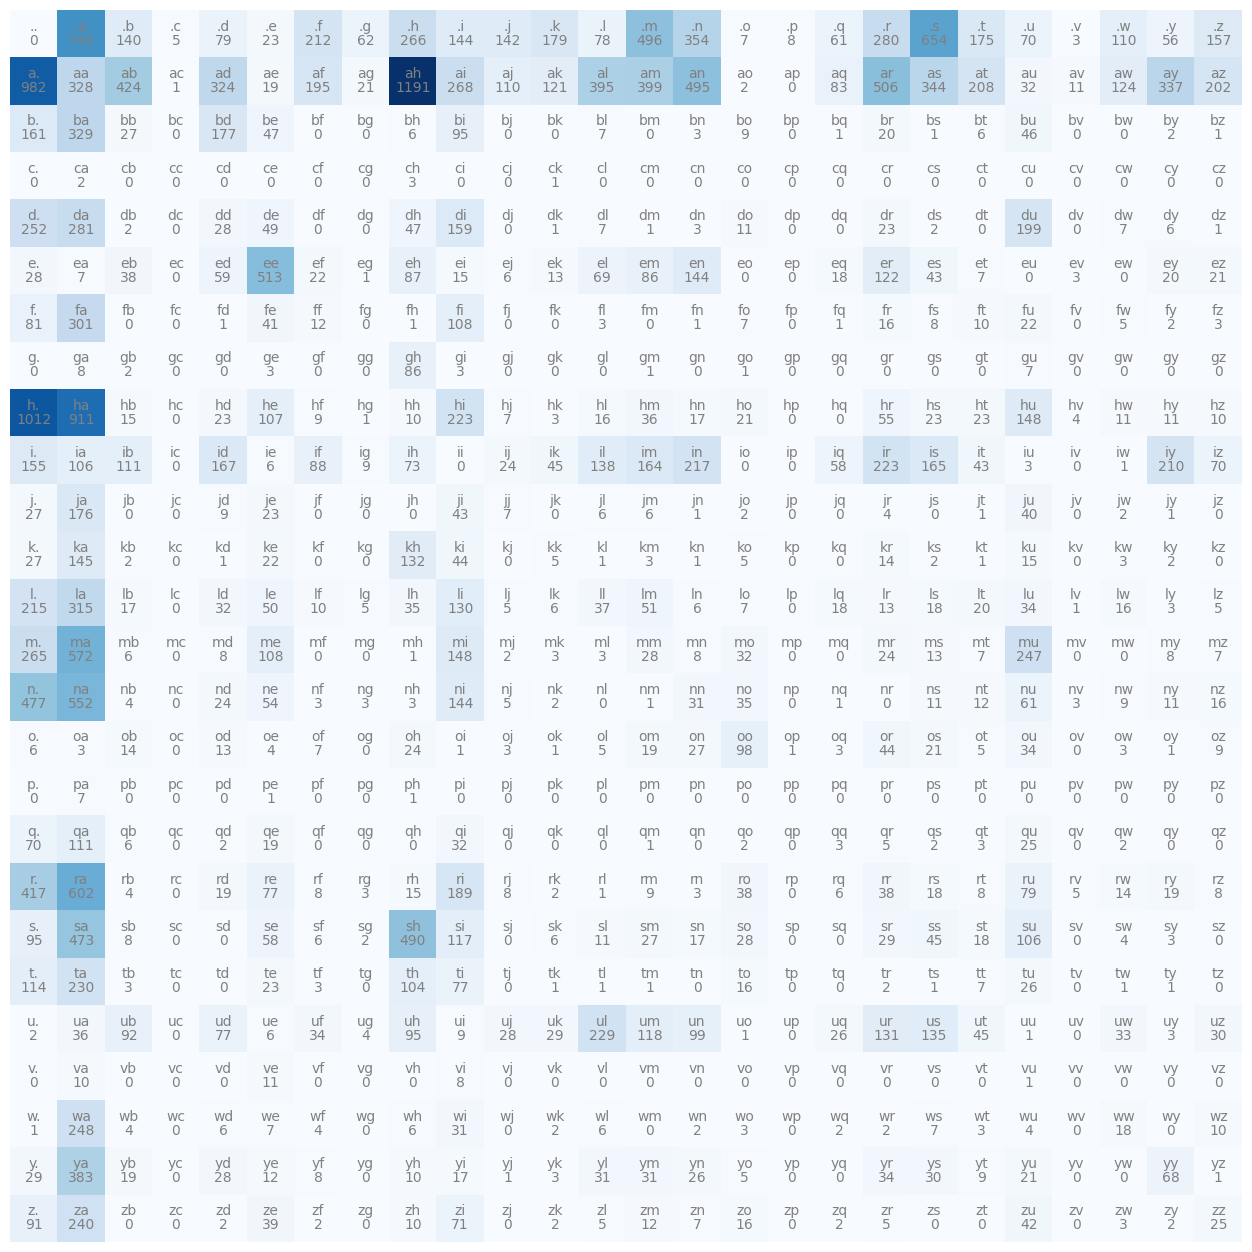

In [283]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(26):
    for j in range(26):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [284]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1655, 0.0311, 0.0011, 0.0175, 0.0051, 0.0470, 0.0138, 0.0590,
        0.0320, 0.0315, 0.0397, 0.0173, 0.1101, 0.0785, 0.0016, 0.0018, 0.0135,
        0.0621, 0.1451, 0.0388, 0.0155, 0.0007, 0.0244, 0.0124, 0.0348])

In [285]:
g = torch.Generator().manual_seed(123)
ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
itos[ix]

'a'

In [286]:
torch.multinomial(p , num_samples= 100, replacement= True, generator=g)

tensor([23, 13, 13,  6, 14,  5, 11,  1,  1, 13,  2, 17, 14, 19, 19, 19, 19, 13,
         4, 23,  6, 11, 20,  4,  1,  9,  1,  8, 25, 19,  1,  8, 23,  9, 19, 25,
        19, 19,  1, 10,  1,  1, 19, 10,  1,  1, 14, 13,  1, 10,  8, 13, 13, 12,
        19,  1, 10, 14, 18, 19, 23,  7,  1, 13, 19, 13, 21, 18, 19, 14, 13, 20,
         7, 10, 20,  6, 20,  1, 11, 20, 14,  1, 21,  1, 19, 13, 10,  1, 14,  6,
        20,  1, 13,  1,  1,  6,  1, 25,  1, 13])

In [287]:
ix = 0
for i in range(20):
    out = []
    while True:
        p = N[ix].float() 
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

sh.
asa.
i.
hufifaraiya.
rzadeeraabish.
muthiyyldh.
sn.
jujaheeebareelid.
abaanudh.
sa.
maladram.
a.
ah.
h.
asaya.
h.
sohi.
ra.
anaamaazeeroddaaba.
ar.


In [288]:
P = N.float()
# print(P.sum(dim=1, keepdim=True))
# print(P.sum(dim=0, keepdim=True))
# both the sum is same due to the nature of bigram statistics - every char that enters as a first character is also a second character to other bigram

In [289]:
#P.sum(dim = 1).shape

In [290]:
P /= P.sum(dim = 1, keepdim= True)
P.shape

torch.Size([26, 26])

In [291]:
ix = 0
for i in range(20):
    out = []
    while True: 
        p = P[ix] # removing the redundant float conversion 
        ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

wd.
d.
adazzah.
sa.
raffawah.
rah.
sashuhaahadanakasasabaladut.
nan.
raddanata.
f.
h.
m.
fwaq.
n.
wanul.
aha.
sabibara.
skinatahamark.
sasrimeeedradah.
sifehsar.


> GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling) <br>
> equivalent to maximizing the log likelihood (because log is monotonic) <br>
> equivalent to minimizing the negative log likelihood <br>
> equivalent to minimizing the average negative log likelihood <br>

In [ ]:
# Evaluating the quality of this model using statistical modelling 
log_likelihood = 0.0
n = 0
for name in names:
    chs =  ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1 # for normalisation purposes
        
print(f'{log_likelihood=}') # for the entire dataset
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-74555.7812)
nll=tensor(74555.7812)
2.2843945026397705


In [ ]:
log_likelihood = 0.0
n = 0
for name in 'muhammad':
    chs =  ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1 # for normalisation purposes
        
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-39.2819)
nll=tensor(39.2819)
2.45511794090271


In [304]:
log_likelihood = 0.0
n = 0
for name in 'john':
    chs =  ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1 # for normalisation purposes
        
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-24.0099)
nll=tensor(24.0099)
3.0012435913085938


Lets now approach the same problem using a Neural Network

In [331]:
xs , ys = [] , []
for name in names[:1]:
    chs = ["."] + list(name) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] 
        ix2 = stoi[ch2] 
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a a
a b
b a
a n
n .


In [332]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes= 26).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]])

In [335]:
xenc.shape

torch.Size([6, 26])

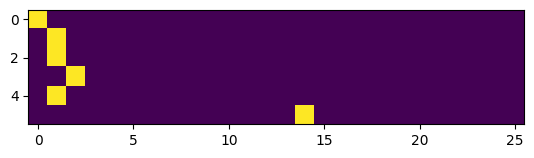

In [333]:
plt.imshow(xenc)

In [336]:
W = torch.randn((26,26))
xenc @ W #6, 26 @ 26, 26 to get the probablities across the vocab

tensor([[ 0.8101,  0.7876, -0.1212,  0.7270,  1.2440,  1.2608,  0.0132, -1.5386,
          1.4278, -0.8834, -0.7482, -0.4658,  0.1325,  0.2969,  0.2244, -0.9700,
         -0.4243,  1.9779, -0.4490, -1.6241,  0.1958, -0.3908,  0.6849, -0.0293,
          0.0334, -1.5029],
        [ 0.6507,  0.7553, -0.5878,  0.7368,  0.9115,  0.1758, -1.7041,  0.3208,
          0.7524, -1.6458,  0.5094, -0.9364,  0.3090, -1.1592,  1.3034,  1.0269,
          0.0665, -0.5356,  0.2945, -1.1505, -0.1172, -0.0428, -1.1621, -0.4464,
          1.1946, -2.7417],
        [ 0.6507,  0.7553, -0.5878,  0.7368,  0.9115,  0.1758, -1.7041,  0.3208,
          0.7524, -1.6458,  0.5094, -0.9364,  0.3090, -1.1592,  1.3034,  1.0269,
          0.0665, -0.5356,  0.2945, -1.1505, -0.1172, -0.0428, -1.1621, -0.4464,
          1.1946, -2.7417],
        [-0.4053, -0.1002, -1.0587, -0.0175,  1.4408, -0.6171,  0.1309,  1.0767,
         -1.2658, -0.6585, -0.0686, -0.3989, -1.4730, -1.3857, -1.4736,  0.5107,
          1.4521, -0.9721

In [337]:
logits = xenc @ W # log counts
counts = logits.exp() # equvialent to N
probs = counts / counts.sum(dim = 1, keepdim= True)
probs

tensor([[0.0559, 0.0546, 0.0220, 0.0514, 0.0862, 0.0877, 0.0252, 0.0053, 0.1036,
         0.0103, 0.0118, 0.0156, 0.0284, 0.0334, 0.0311, 0.0094, 0.0163, 0.1796,
         0.0159, 0.0049, 0.0302, 0.0168, 0.0493, 0.0241, 0.0257, 0.0055],
        [0.0565, 0.0627, 0.0164, 0.0616, 0.0733, 0.0351, 0.0054, 0.0406, 0.0625,
         0.0057, 0.0491, 0.0116, 0.0401, 0.0092, 0.1085, 0.0823, 0.0315, 0.0173,
         0.0396, 0.0093, 0.0262, 0.0282, 0.0092, 0.0189, 0.0973, 0.0019],
        [0.0565, 0.0627, 0.0164, 0.0616, 0.0733, 0.0351, 0.0054, 0.0406, 0.0625,
         0.0057, 0.0491, 0.0116, 0.0401, 0.0092, 0.1085, 0.0823, 0.0315, 0.0173,
         0.0396, 0.0093, 0.0262, 0.0282, 0.0092, 0.0189, 0.0973, 0.0019],
        [0.0219, 0.0297, 0.0114, 0.0323, 0.1387, 0.0177, 0.0374, 0.0963, 0.0093,
         0.0170, 0.0306, 0.0220, 0.0075, 0.0082, 0.0075, 0.0547, 0.1402, 0.0124,
         0.0546, 0.0489, 0.0745, 0.0423, 0.0165, 0.0199, 0.0151, 0.0334],
        [0.0565, 0.0627, 0.0164, 0.0616, 0.0733, 0.0351,

In [338]:
probs[0].shape

torch.Size([26])

In [340]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .a (indexes 0,1)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0559, 0.0546, 0.0220, 0.0514, 0.0862, 0.0877, 0.0252, 0.0053, 0.1036,
        0.0103, 0.0118, 0.0156, 0.0284, 0.0334, 0.0311, 0.0094, 0.0163, 0.1796,
        0.0159, 0.0049, 0.0302, 0.0168, 0.0493, 0.0241, 0.0257, 0.0055])
label (actual next character): 1
probability assigned by the net to the the correct character: 0.05461283028125763
log likelihood: -2.9074864387512207
negative log likelihood: 2.9074864387512207
--------
bigram example 2: aa (indexes 1,1)
input to the neural net: 1
output probabilities from the neural net: tensor([0.0565, 0.0627, 0.0164, 0.0616, 0.0733, 0.0351, 0.0054, 0.0406, 0.0625,
        0.0057, 0.0491, 0.0116, 0.0401, 0.0092, 0.1085, 0.0823, 0.0315, 0.0173,
        0.0396, 0.0093, 0.0262, 0.0282, 0.0092, 0.0189, 0.0973, 0.0019])
label (actual next character): 1
probability assigned by the net to the the correct character: 0.0627247244119644

In [341]:
# Lets now optimise this model
xs

tensor([ 0,  1,  1,  2,  1, 14])

In [342]:
ys

tensor([ 1,  1,  2,  1, 14,  0])

In [349]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(1234)
W = torch.randn((26, 26), generator=g, requires_grad=True)

In [350]:
# forward pass
xenc = F.one_hot(xs, num_classes=26).float()
logits = xenc @ W 
counts = logits.exp()
probs = counts/ counts.sum(dim = 1, keepdim=True) # probabilities for the next character
loss = - probs[torch.arange(6), ys].log().mean()

In [351]:
print(loss.item())

3.5415773391723633


In [357]:
# backward pass
W.grad = None
loss.backward()
W.data += -0.1 * W.grad

In [359]:
# create the dataset
xs, ys = [], []
for name in names:
  chs = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(1234)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  32637


In [363]:
# implementing gradient descent
for k in range(200):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() # applying regularisation 
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

2.324112892150879
2.3239688873291016
2.3238279819488525
2.3236899375915527
2.3235552310943604
2.323423147201538
2.323294162750244
2.323167562484741
2.3230435848236084
2.3229222297668457
2.322803258895874
2.3226869106292725
2.322572708129883
2.322460651397705
2.3223512172698975
2.3222436904907227
2.3221378326416016
2.3220345973968506
2.3219330310821533
2.321833610534668
2.3217358589172363
2.3216400146484375
2.3215460777282715
2.32145357131958
2.3213632106781006
2.321274518966675
2.3211870193481445
2.321101188659668
2.321017026901245
2.3209340572357178
2.320852518081665
2.320773124694824
2.3206944465637207
2.320617198944092
2.3205413818359375
2.320466995239258
2.3203935623168945
2.320321559906006
2.3202507495880127
2.320180892944336
2.320112466812134
2.320044994354248
2.319978952407837
2.319913387298584
2.3198494911193848
2.319786548614502
2.3197238445281982
2.3196632862091064
2.3196029663085938
2.3195436000823975
2.3194854259490967
2.319427728652954
2.319371461868286
2.3193159103393555


In [366]:
# making inference  ie finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(1234)

for i in range(100):
  
  out = []
  ix = 0
  while True:

    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

azasayshaamaad.
idayyala.
ra.
n.
naaatauramenssrsh.
hoba.
nn.
marahun.
m.
warayahil.
sulnahusbedayahamusanaamima.
ahuhaimana.
k.
ndisn.
taizanabah.
kah.
adajah.
fida.
alamiqagh.
m.
am.
faradim.
uaridaramah.
mdimahahkanhuwan.
kha.
kagamennadeeeb.
kanasmudurah.
mazzen.
sh.
zaha.
nahoooon.
kushahabafahah.
mah.
feredusmuta.
h.
usarahtamiyatahiafvidazayan.
sh.
juromadim.
a.
hifiydosheerreq.
nah.
brahawim.
aq.
habdulan.
maltinanana.
lifirayasaizah.
b.
ma.
ke.
tt.
th.
rum.
n.
ateeemizz.
safeenabukajabayaraham.
aimamaffa.
hemshah.
ldiseidanuhawahisa.
ara.
jah.
lalahahaidaya.
ma.
sshiladubahl.
sahahaas.
stanilawikahtatpdaidrabd.
ahuh.
a.
yghibaish.
jileeh.
ulbdqsuofi.
amooal.
ahsifibalinid.
uqeyafahaharatula.
alisab.
sh.
lir.
hiaib.
sera.
habah.
masayadaymall.
sr.
khusa.
sarijiynjkah.
ushimufamahadahabilab.
j.
wam.
laz.
mularidusiz.
wwayaadjafatasukafiroa.
khazzibd.
gh.
aimada.
narabbvihbwbeeebin.
mahafam.
n.
sh.
aaqqaisa.
kir.
afaih.
umah.
